In [1]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

# Note: Ensure PCHs are correctly installed/imported
from causal_gym.envs import FrozenLakePCH 
# This is a test modification

In [2]:
SEED = 6458 # Same seed as lava example for consistency
USE_SPRITE_RENDERING = False # True for sprites (separate window), False for simple squares (in notebook)

# Helper function to display rendered environment images
def show_obs(img_arg, env, name=None): # img_arg is the result of env.render()
    img = img_arg.copy()
    
    unwrapped_scm = env.unwrapped # This is typically the SCM (FrozenLakeSCM or WindyFrozenLakeSCM)
    
    apply_texture = False
    texture_color = np.array([170, 190, 220], dtype=np.uint8) # Default icy blue for wind/slippery
    
    # Default colors/sizes if not found in SCM (e.g. older SCM version)
    # These should ideally match what the SCM's render method uses.
    original_f_color = np.array([214, 234, 248], dtype=np.uint8) # Actual COLOR_FROZEN from FrozenLakeSCM
    current_tile_size = 32 # Actual TILE_SIZE from FrozenLakeSCM

    true_base_gym_env = None

    if hasattr(unwrapped_scm, 'base_env'): # Indicates it's WindyFrozenLakeSCM
        # This is WindyFrozenLakeSCM, which wraps a FrozenLakeSCM
        actual_scm_for_render_params = unwrapped_scm.base_env
        true_base_gym_env = unwrapped_scm.base_env.env.unwrapped
        
        if unwrapped_scm.current_wind_direction != cgym.envs.windy_frozen_lake.WIND_NONE:
            apply_texture = True
    elif hasattr(unwrapped_scm, 'env'): # Indicates it's the original FrozenLakeSCM
        actual_scm_for_render_params = unwrapped_scm
        true_base_gym_env = unwrapped_scm.env.unwrapped
        
        if actual_scm_for_render_params.is_slippery:
            apply_texture = True
    else:
        print("Warning: Could not determine SCM type for texture logic.")

    if true_base_gym_env is not None:
        desc = true_base_gym_env.desc
        nrow = true_base_gym_env.nrow
        ncol = true_base_gym_env.ncol
        # Use TILE_SIZE from the SCM that does the rendering (FrozenLakeSCM)
        current_tile_size = getattr(actual_scm_for_render_params, 'TILE_SIZE', current_tile_size)
        # Use COLOR_FROZEN from the SCM for mask
        original_f_color = getattr(actual_scm_for_render_params, 'COLOR_FROZEN', original_f_color)

    if apply_texture and true_base_gym_env is not None:
        for r_idx in range(nrow):
            for c_idx in range(ncol):
                if desc[r_idx, c_idx] == b'F': 
                    tile_y_start, tile_y_end = r_idx * current_tile_size, (r_idx + 1) * current_tile_size
                    tile_x_start, tile_x_end = c_idx * current_tile_size, (c_idx + 1) * current_tile_size
                    tile_pixels_slice = img[tile_y_start:tile_y_end, tile_x_start:tile_x_end]
                    mask = np.all(tile_pixels_slice == original_f_color, axis=-1)
                    tile_pixels_slice[mask] = texture_color
    
    plt.imshow(img)
    plt.axis('off')

    if name is not None:
        plt.tight_layout()
        fig = plt.gcf()
        fig.set_size_inches(6, 6)
    plt.show()

[DEBUG] Initializing Pygame...
Initial state (reset with SEED), Wind: None


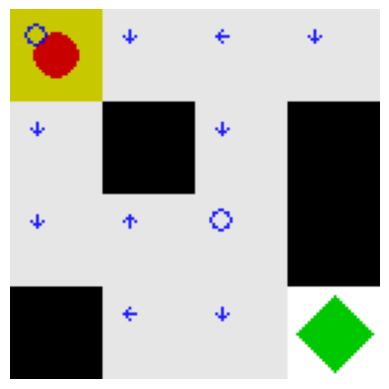

In [3]:
# Create the WindyFrozenLake environment
current_render_mode = 'human' if USE_SPRITE_RENDERING else 'rgb_array'

# Parameters for WindyFrozenLakeSCM itself (e.g., wind probabilities)
windy_params = {
    'wind_probabilities': (0.2, 0.2, 0.2, 0.2, 0.2), # Example: equal chance for all wind states (including None)
    # 'render_mode': current_render_mode # This will be passed to WindyFrozenLakeSCM constructor
}

# Use gym.make to get the PCH, as causal_gym registers its envs with Gymnasium
# The kwargs passed to make are for the PCH's SCM (WindyFrozenLakeSCM in this case)
env = gym.make(
    "causal_gym/FrozenLakePCH-v0", 
    is_slippery=True, 
    wind_probabilities=windy_params['wind_probabilities'],
     # Pass render_mode for PCH/SCM wrapper consistency if needed by them
    render_mode=current_render_mode,
)

# Reset the environment with the seed
_, info = env.reset(seed=SEED)
print(f"Initial state (reset with SEED), Wind: {info.get('wind_direction')}")

if not USE_SPRITE_RENDERING:
    rendered_img = env.render()
    if rendered_img is not None:
        show_obs(rendered_img, env) # Pass PCH env to show_obs
else:
    env.render() # Update external window if 'human'

State after forced action 2 (Right):
Reward: 0.16666666666666666, Done: False


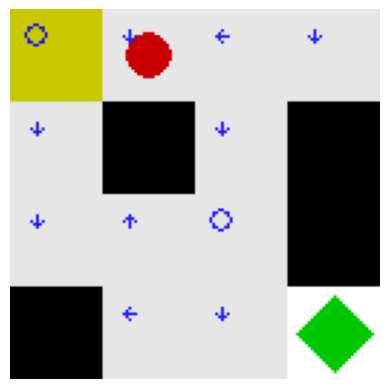

In [4]:
# Perform an observational step (see) using a fixed policy (always action 2: Right)
# Note: FrozenLakePCH.see() doesn't take bpolicy directly.
# We'll simulate by getting the default action (random in slippery mode)
# and then *showing* the result if we had *forced* action 2 (RIGHT)
# This isn't a perfect match to the lava notebook's 'see' with policy,
# but illustrates the environment state after a 'do' action.

TARGET_ACTION = 2 # Right

# Get current state before taking action
current_obs, _ = env.reset(seed=SEED) # Re-reset to ensure starting state

# Perform the 'do' action
obs, r, done, _, info = env.do(TARGET_ACTION) # Use do for a specific action

print(f"State after forced action {TARGET_ACTION} (Right):")
print(f"Reward: {r}, Done: {done}")
if not USE_SPRITE_RENDERING:
    show_obs(env.render(), env) # Pass env
else:
    env.render() # Update external window


Initial state (reset with SEED2):


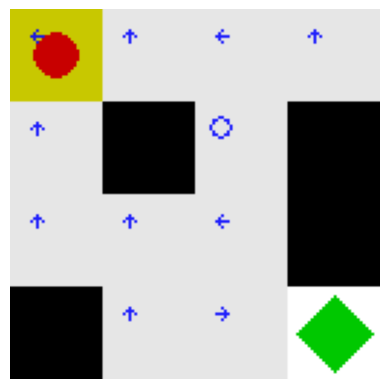

In [5]:
# Reset with a different seed
SEED2 = 1234
_, info = env.reset(seed=SEED2)
print("\nInitial state (reset with SEED2):")
if not USE_SPRITE_RENDERING:
    show_obs(env.render(), env) # Pass env
else:
    env.render() # Update external window

State after forced action 2 (Right) from SEED2 state:
Reward: 0.16666666666666666, Done: False


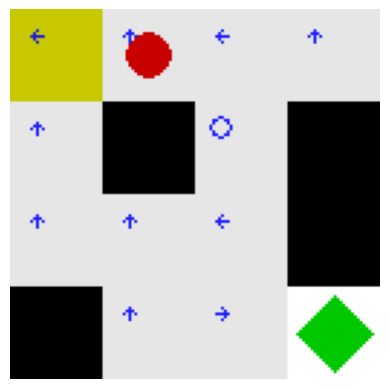

In [6]:
# Perform another 'do' action from the new state
obs, r, done, _, info = env.do(TARGET_ACTION) # Use do for a specific action

print(f"State after forced action {TARGET_ACTION} (Right) from SEED2 state:")
print(f"Reward: {r}, Done: {done}")
if not USE_SPRITE_RENDERING:
    show_obs(env.render(), env) # Pass env
else:
    env.render() # Update external window

env.close() # Close the environment when done

In [7]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

def display_frames(frames, figsize=(10, 8)):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            plt.tight_layout()
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            from IPython.display import HTML
            plt.close(fig) # close the static plot
            display(HTML(anim.to_jshtml()))
            print("Displaying animation.")

In [10]:
frames = []
env = gym.make("causal_gym/FrozenLakePCH-v0", is_slippery=True, wind_probabilities=(0.2, 0.2, 0.2, 0.2, 0.2), render_mode='rgb_array')
_, info = env.reset(seed=1234)
obs = env.render()
frames.append(obs)

for _ in range(20):  # Simulate a few steps
    action, state, reward, term, trunc, info = env.see()
    frames.append(env.render())
    if term or trunc:
        break

display_frames(frames)

Displaying animation.
